In [128]:
import pandas as pd

In [129]:
df = pd.read_csv("train.csv")

In [130]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [131]:
df.shape

(1460, 81)

In [132]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [133]:
df.info

<bound method DataFrame.info of         Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour Ut

In [134]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [135]:
df["PoolQC"] = df["PoolQC"].fillna("No Pool")
df["Fence"] = df["Fence"].fillna("No Fence")
df["Alley"] = df["Alley"].fillna("No Alley")

In [136]:
with open("data_description.txt", "r") as file:
    for line in file:
        if "MiscFeature" in line:
            print(line.strip())

MiscFeature: Miscellaneous feature not covered in other categories


In [137]:
df["MasVnrType"].value_counts(dropna=False)

MasVnrType
NaN        872
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

In [138]:
df["MasVnrArea"].value_counts(dropna=False).head(20)

MasVnrArea
0.0      861
108.0      8
NaN        8
72.0       8
180.0      8
120.0      7
16.0       7
340.0      6
106.0      6
200.0      6
80.0       6
170.0      5
320.0      5
84.0       5
132.0      5
360.0      5
246.0      4
216.0      4
270.0      4
210.0      4
Name: count, dtype: int64

In [139]:
df[df["MasVnrType"].isnull()][["MasVnrType", "MasVnrArea"]].head(20)

,MasVnrType,MasVnrArea
1,NaN,0.0
3,NaN,0.0
5,NaN,0.0
8,NaN,0.0
9,NaN,0.0
10,NaN,0.0
12,NaN,0.0
15,NaN,0.0
17,NaN,0.0
18,NaN,0.0


In [140]:
df["MasVnrType"] = df["MasVnrType"].fillna("None")

In [141]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

MiscFeature     1406
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [142]:
garage_columns = ["GarageType", "GarageFinish", "GarageQual", "GarageCond"]
for col in garage_columns:
    df[col] = df[col].fillna("No Garage")

In [143]:
basement_clmn = [ "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"]

for col in basement_clmn:
    df[col] = df[col].fillna("No Basement")

In [144]:
df[df["Electrical"].isnull()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1379,1380,80,RL,73.0,9735,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,No Fence,NaN,0,5,2008,WD,Normal,167500


In [145]:
df[df["MasVnrArea"].isnull()][["MasVnrType", "MasVnrArea"]]

,MasVnrType,MasVnrArea
234,None,NaN
529,None,NaN
650,None,NaN
936,None,NaN
973,None,NaN
977,None,NaN
1243,None,NaN
1278,None,NaN


In [146]:
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

In [147]:
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

In [148]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [149]:
df["LotFrontage"].describe()

count    1201.000000
mean       70.049958
std        24.284752
min        21.000000
25%        59.000000
50%        69.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64

<Axes: >

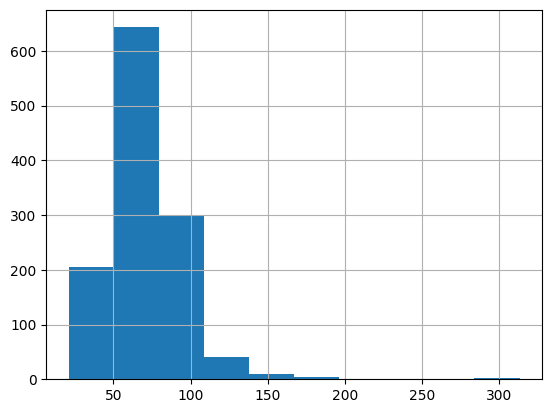

In [150]:
df["LotFrontage"].hist()

In [151]:
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())

In [152]:
df.isnull().sum().sum()

np.int64(2177)

In [153]:
df.isnull().sum()[df.isnull().sum() > 0]

FireplaceQu     690
GarageYrBlt      81
MiscFeature    1406
dtype: int64

In [154]:
df["FireplaceQu"] = df["FireplaceQu"].fillna("No Fireplace")

In [155]:
df["MiscFeature"] = df["MiscFeature"].fillna("None")

In [156]:
df[df["GarageYrBlt"].isnull()][["GarageType", "GarageYrBlt"]].head(10)

,GarageType,GarageYrBlt
39,No Garage,NaN
48,No Garage,NaN
78,No Garage,NaN
88,No Garage,NaN
89,No Garage,NaN
99,No Garage,NaN
108,No Garage,NaN
125,No Garage,NaN
127,No Garage,NaN
140,No Garage,NaN


In [157]:
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

In [158]:
df.isnull().sum().sum()

np.int64(0)

In [159]:
df.select_dtypes(include="object").shape

(1460, 43)

In [160]:
df.select_dtypes(exclude="object").shape

(1460, 38)

In [161]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [162]:
print(X.shape)
print(y.shape)

(1460, 80)
(1460,)


In [163]:
num_cols= X.select_dtypes(exclude = "object").columns
cat_cols = X.select_dtypes(include="object").columns

In [164]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [165]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

In [166]:
X_transformed = preprocessor.fit_transform(X)
print(X_transformed.shape)

(1460, 303)


In [167]:
from sklearn.model_selection import train_test_split

In [168]:
X_train,X_test,y_train,y_test = train_test_split(
    X_transformed,
    y,
    test_size=0.2,
    random_state=42
)

In [169]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [170]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [171]:
y_pred = lr.predict(X_test)
print(y_pred)

[154673.43754992 344259.82918641 102132.87053827 191811.80960226
 326544.67995947  66227.91158992 250713.96087724 145675.48513335
  60555.39341439 148130.01860414 141758.08244256 103697.4979729
  93394.98242308 231020.1455839  173348.94443973 135518.07172828
 188908.46710884 126120.46721737 129048.41765261 208929.16014078
 159154.76698655 204662.95153762 182774.83013837 134093.52691152
 199379.69945926 143433.44541914 200620.32237889 101080.57156838
 169727.95558989 212810.8775256  119290.77170345 276844.00570241
 236511.56470183 113854.0284754  244039.95711755 140734.91702273
 137409.25997453 209791.65226042 319787.76478188 103356.82012709
 137760.05859019 222810.43383507 100028.9762099  350145.59861728
 126965.89124728 133715.25009379 100187.85447188 137781.56751645
 407009.67726244 130911.5855449  124730.34459994 246762.08853944
  96260.91427243 251546.53357975 166887.60336184 227072.01665105
 205294.97636406 173556.95244654 132326.87392135  94141.41122433
  46889.27471621 172669.30

In [172]:
from sklearn.metrics import mean_absolute_error

In [173]:
mae = mean_absolute_error(y_test,y_pred)
print("MAE:",mae)

MAE: 20429.075934601082


In [174]:
from sklearn.metrics import root_mean_squared_error

In [175]:
rmse = root_mean_squared_error(y_test,y_pred)
print("RMSE:",rmse)

RMSE: 30669.64944735377


In [176]:
from sklearn.metrics import r2_score

In [177]:
r2 = r2_score(y_test,y_pred)
print("R2_score: ",r2)

R2_score:  0.8773680060253245
